<a href="https://colab.research.google.com/github/Aaryan8597/AI-ML-Aaryan_Lamichhane_2408597-CourseWork/blob/main/Aaryan_Lamichhane_2408597_Code_Text_Classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Necessary Imports

In [ ]:
!pip install gensim

In [ ]:
!pip install contractions

In [ ]:
import pandas as pd
import numpy as np
import re
import time

import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

nltk.download('stopwords')
nltk.download('wordnet')

import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.text import Tokenizer
from sklearn.model_selection import train_test_split
from tensorflow.keras.preprocessing.sequence import pad_sequences

from tensorflow.keras.models import Sequential,load_model
from tensorflow.keras.layers import Embedding, SimpleRNN, Dense, LSTM

from sklearn.preprocessing import LabelEncoder

from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping

from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

import gensim.downloader as api

import contractions

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


# 4.5.1 Text Preprocessing, Tokenization, and Sequence Padding



## Loading the dataset

In [ ]:
df = pd.read_csv("/content/drive/MyDrive/Aaryan_lamichhane_Task2/6. News Category Dataset/news_category.csv")
df.head()


,headline,category
0,How A New Documentary Captures The Complexity ...,CULTURE & ARTS
1,Twitch Bans Gambling Sites After Streamer Scam...,TECH
2,'Reboot' Is A Clever And Not Too Navel-Gazey L...,CULTURE & ARTS
3,"Maury Wills, Base-Stealing Shortstop For Dodge...",SPORTS
4,"Las Vegas Aces Win First WNBA Title, Chelsea G...",SPORTS


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11025 entries, 0 to 11024
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   headline  11025 non-null  object
 1   category  11025 non-null  object
dtypes: object(2)
memory usage: 172.4+ KB


## Text Cleaning


In [ ]:
def handle_contractions(text):
    return contractions.fix(text)

In [ ]:
def make_lowercase(text):
  #converting to lowercase
  return text.lower()

#for removing url
def remove_urls(text):
  return re.sub(r'https?://\S+|www\.\S+', '', text)

#for removing mention hashtags
def remove_mentions_hashtags(text):
    #removing mentions (@user)
    text = re.sub(r'@\w+', '', text)
    #removing hashtags(#)
    text = re.sub(r'#\w+', '', text)
    return text

#for removing special characters
def remove_special_chars(text):
    return re.sub(r'[^a-zA-Z\s]', '', text)

# for tokenization
def tokenize(text):
    return text.split()

#for stopword removal
stop_words = set(stopwords.words('english'))
custom_stopwords = ['@', 'rt']
stop_words.update(custom_stopwords)

#function for removing stop words
def remove_stopwords(text_tokens):
    result_tokens = []
    for token in text_tokens:
        if token not in stop_words:
            result_tokens.append(token)

    return result_tokens

#function for lemmatization
def lemmatization(token_text):
    wordnet = WordNetLemmatizer()
    lemmatized_tokens = [
        wordnet.lemmatize(token, pos='v')
        for token in token_text
    ]

    return lemmatized_tokens

In [ ]:
def text_cleaning_pipeline(text):

    text = make_lowercase(text)
    text = handle_contractions(text)
    text = remove_urls(text)
    text = remove_mentions_hashtags(text)
    text = remove_special_chars(text)

    tokens = tokenize(text)
    tokens = remove_stopwords(tokens)
    tokens = lemmatization(tokens)

    return " ".join(tokens)

In [ ]:
df['cleaned_text'] = df['headline'].apply(text_cleaning_pipeline)

## VIsualization of cleaned text

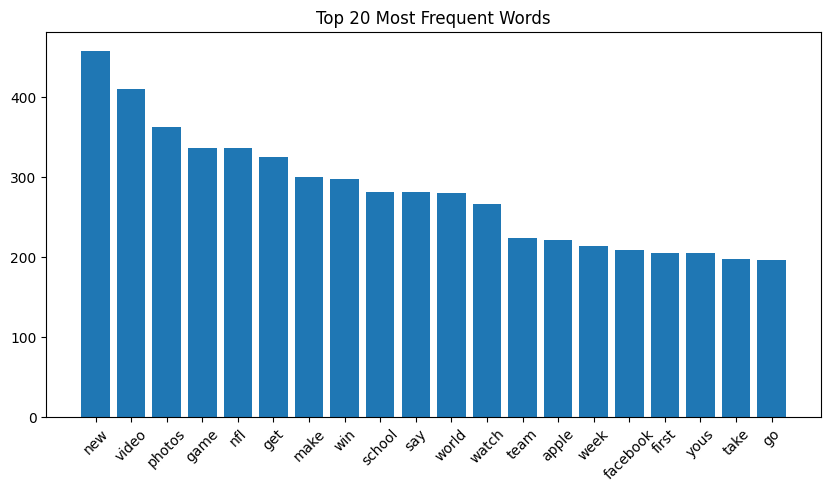

In [ ]:
#getting all words from cleaned text
all_words = ' '.join(df['cleaned_text']).split()

#counting frequency using dictionary
freq = {}
for word in all_words:
    freq[word] = freq.get(word, 0) + 1

#getting top 20
top_items = sorted(freq.items(), key=lambda x: x[1], reverse=True)[:20]

#creating lists for plotting
words = [item[0] for item in top_items]
counts = [item[1] for item in top_items]

plt.figure(figsize=(10, 5))
plt.bar(words, counts)
plt.xticks(rotation=45)
plt.title('Top 20 Most Frequent Words')
plt.show()

## Tokenization and Padding

### Splitting into train and test (80/20)

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(df['cleaned_text'], df['category'], train_size=0.8,test_size=0.2)

### Keras Tokenizer

In [ ]:
tokenizer = Tokenizer()
tokenizer.fit_on_texts(X_train)

#converting text to dequences
X_train_seq = tokenizer.texts_to_sequences(X_train)
X_test_seq = tokenizer.texts_to_sequences(X_test)

### Applying Padding

In [ ]:
#calculating length one by one
sequence_lengths = []
for seq in X_train_seq:
    length = len(seq)
    sequence_lengths.append(length)
#finding 95th percentile
max_length = int(np.percentile(sequence_lengths, 95))
print(max_length)

#applying padding
X_train_pad = pad_sequences(X_train_seq, maxlen=max_length, padding='post')
X_test_pad = pad_sequences(X_test_seq, maxlen=max_length, padding='post')
print(f"Final padded shape: {X_train_pad.shape}")


11
Final padded shape: (8820, 11)


# 4.5.2 Model Building


## Simple RNN

### Simple RNN with a trainable embedding layer

In [ ]:
encoder = LabelEncoder()
y_train_encoded = encoder.fit_transform(y_train)
y_test_encoded = encoder.transform(y_test)

num_classes = len(encoder.classes_)
print(f"Number of categories: {num_classes}")
print(f"Categories: {encoder.classes_}")

vocab_size = len(tokenizer.word_index) + 1
print(f"Vocabulary size: {vocab_size}")

Number of categories: 5
Categories: ['CULTURE & ARTS' 'EDUCATION' 'MONEY' 'SPORTS' 'TECH']
Vocabulary size: 11507


In [ ]:
rnn_model = Sequential()
rnn_model.add(Embedding(input_dim = vocab_size, output_dim = 64, input_length = max_length))
rnn_model.add(SimpleRNN(32))
rnn_model.add(Dense(num_classes, activation='softmax'))

rnn_model.build(input_shape=(None, max_length))

#compiling the model
rnn_model.compile(optimizer = 'adam', loss = "sparse_categorical_crossentropy", metrics = ['accuracy'])
rnn_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 11, 64)         │       736,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ (None, 32)             │         3,104 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 5)              │           165 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 739,717 (2.82 MB)

 Trainable params: 739,717 (2.82 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model_path = "/content/drive/MyDrive/simple_rnn_best_model.h5"
checkpoint = ModelCheckpoint(filepath = model_path, monitor='val_accuracy', save_best_only=True,)
early_stop = EarlyStopping( monitor='val_loss', patience=3, restore_best_weights=True)

In [ ]:
start_time = time.time()

history_rnn = rnn_model.fit(
    X_train_pad,
    y_train_encoded,
    validation_split=0.2,
    epochs=15,
    batch_size=32,
    callbacks=[checkpoint, early_stop]
)
end_time = time.time()
training_time = end_time - start_time

print("Training Time for SImple RNN model :", training_time)

Epoch 1/15
221/221 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.5413 - loss: 1.2021

221/221 ━━━━━━━━━━━━━━━━━━━━ 8s 28ms/step - accuracy: 0.6424 - loss: 0.9696 - val_accuracy: 0.7426 - val_loss: 0.7128
Epoch 2/15
221/221 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.8931 - loss: 0.3515

221/221 ━━━━━━━━━━━━━━━━━━━━ 10s 28ms/step - accuracy: 0.8977 - loss: 0.3258 - val_accuracy: 0.7642 - val_loss: 0.6860
Epoch 3/15
218/221 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.9795 - loss: 0.0920

221/221 ━━━━━━━━━━━━━━━━━━━━ 5s 21ms/step - accuracy: 0.9773 - loss: 0.0947 - val_accuracy: 0.7715 - val_loss: 0.7418
Epoch 4/15
221/221 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - accuracy: 0.9909 - loss: 0.0407 - val_accuracy: 0.7704 - val_loss: 0.8138
Epoch 5/15
221/221 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.9949 - loss: 0.0235 - val_accuracy: 0.7511 - val_loss: 0.9389
Training Time for SImple RNN model : 31.42297077178955


### Model Evaluation

In [ ]:
rnn_model = load_model("/content/drive/MyDrive/simple_rnn_best_model.h5")
# evaluating test accuracy
test_loss, test_accuracy = rnn_model.evaluate(X_test_pad, y_test_encoded)

print("Test Loss for RNN:", test_loss)
print("Test Accuracy for RNN:", test_accuracy)

69/69 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7932 - loss: 0.7384
Test Loss for RNN: 0.7383872270584106
Test Accuracy for RNN: 0.7931972742080688


In [ ]:
y_pred_probs = rnn_model.predict(X_test_pad)

y_pred_rnn = np.argmax(y_pred_probs, axis=1)

69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step


In [ ]:
target_names = encoder.classes_

print(classification_report(y_test_encoded, y_pred_rnn, target_names=target_names))

                precision    recall  f1-score   support

CULTURE & ARTS       0.70      0.41      0.52       215
     EDUCATION       0.64      0.69      0.66       213
         MONEY       0.74      0.74      0.74       340
        SPORTS       0.85      0.93      0.89      1004
          TECH       0.80      0.76      0.78       433

      accuracy                           0.79      2205
     macro avg       0.74      0.71      0.72      2205
  weighted avg       0.79      0.79      0.79      2205



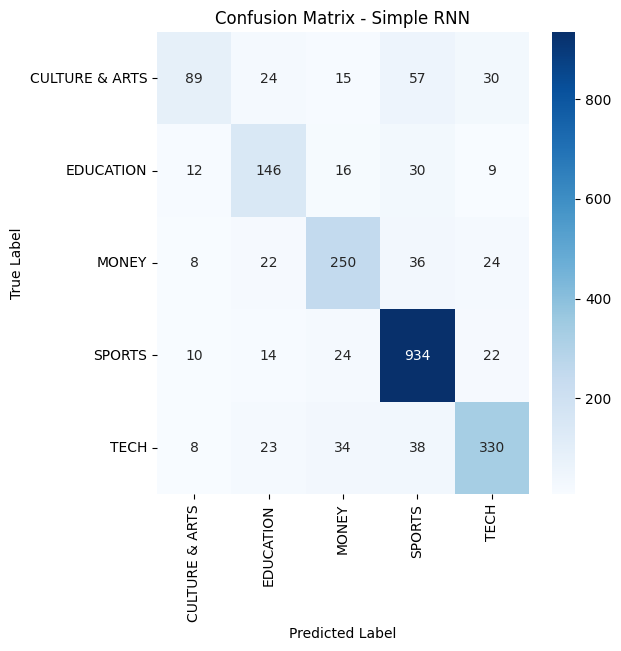

In [ ]:
#confusion matrix
confusion_matrix_RNN = confusion_matrix(y_test_encoded, y_pred_rnn)

plt.figure(figsize=(6,6))
sns.heatmap(confusion_matrix_RNN, annot=True, fmt = 'd', cmap='Blues',
           xticklabels=encoder.classes_, yticklabels=encoder.classes_)
plt.title("Confusion Matrix - Simple RNN")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

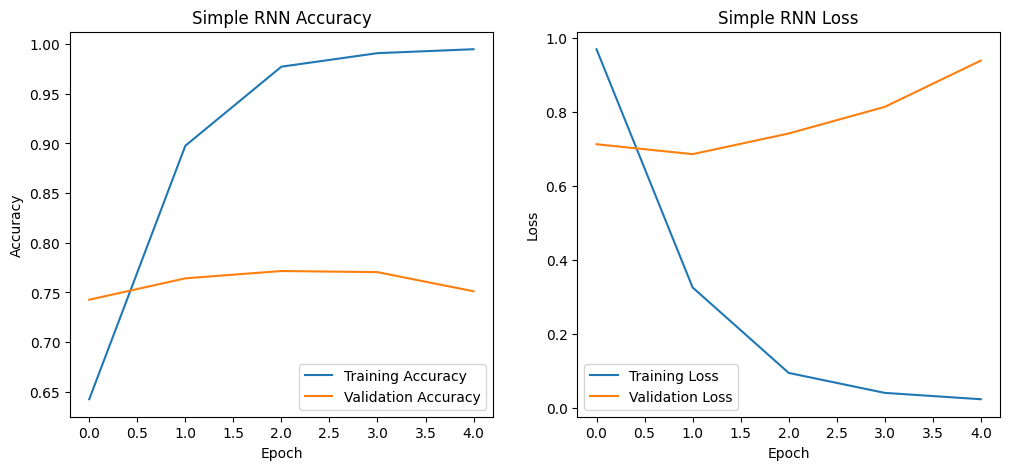

In [ ]:
plt.figure(figsize=(12,5))
#accuracy graph
plt.subplot(1,2,1)
plt.plot(history_rnn.history['accuracy'])
plt.plot(history_rnn.history['val_accuracy'])

plt.title("Simple RNN Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.legend(['Training Accuracy', 'Validation Accuracy'])

#loss graph
plt.subplot(1,2,2)
plt.plot(history_rnn.history['loss'])
plt.plot(history_rnn.history['val_loss'])

plt.title("Simple RNN Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend(['Training Loss', 'Validation Loss'])
plt.show()

## LSTM with a trainable Embedding layer

In [ ]:
lstm_model = Sequential()
lstm_model.add(Embedding(input_dim=vocab_size,output_dim=64,input_length=max_length))
#LSTM Layer
lstm_model.add(LSTM(32))
# Dense Output Layer
lstm_model.add(Dense(num_classes, activation='softmax'))

lstm_model.build(input_shape=(None, max_length))
lstm_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ (None, 11, 64)         │       736,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 5)              │           165 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 749,029 (2.86 MB)

 Trainable params: 749,029 (2.86 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
lstm_model_path = "/content/drive/MyDrive/lstm_best_model.h5"
#callbacks
checkpoint = ModelCheckpoint( filepath=lstm_model_path, monitor='val_accuracy', save_best_only=True,)
early_stop = EarlyStopping( monitor='val_loss', patience=3, restore_best_weights=True)
#compiling the model
lstm_model.compile( optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

In [ ]:
start_time = time.time()

history_lstm = lstm_model.fit(
    X_train_pad, y_train_encoded,
    validation_split=0.2,
    epochs=15,
    batch_size=32,
    callbacks=[checkpoint, early_stop]
)
training_time_lstm = time.time() - start_time
print("\nLSTM Training Time:", training_time_lstm)

Epoch 1/15
220/221 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.4822 - loss: 1.3236

221/221 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - accuracy: 0.5682 - loss: 1.1058 - val_accuracy: 0.6587 - val_loss: 0.8462
Epoch 2/15
220/221 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.7761 - loss: 0.6134

221/221 ━━━━━━━━━━━━━━━━━━━━ 4s 19ms/step - accuracy: 0.8160 - loss: 0.5249 - val_accuracy: 0.8027 - val_loss: 0.5662
Epoch 3/15
218/221 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9445 - loss: 0.2066

221/221 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - accuracy: 0.9416 - loss: 0.2031 - val_accuracy: 0.8192 - val_loss: 0.5767
Epoch 4/15
221/221 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.9762 - loss: 0.0864 - val_accuracy: 0.8027 - val_loss: 0.6804
Epoch 5/15
221/221 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - accuracy: 0.9882 - loss: 0.0459 - val_accuracy: 0.7982 - val_loss: 0.7936

LSTM Training Time: 16.894437551498413


### Evaluation of LSTM

In [ ]:
lstm_model = load_model("/content/drive/MyDrive/lstm_best_model.h5")
test_loss_lstm, test_accuracy_lstm = lstm_model.evaluate(X_test_pad, y_test_encoded)

print("Test Loss for LSTM model:", test_loss)
print("Test Accuracy for LSTM model:", test_accuracy)

69/69 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8263 - loss: 0.5687
Test Loss for LSTM model: 0.7383872270584106
Test Accuracy for LSTM model: 0.7931972742080688


In [ ]:
y_pred_probs = lstm_model.predict(X_test_pad)
y_pred_lstm = np.argmax(y_pred_probs, axis=1)

69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step


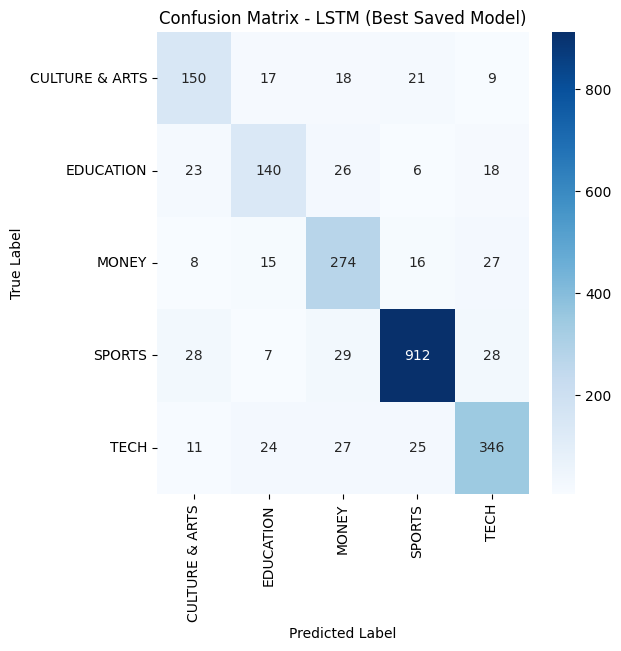

In [ ]:
confusion_matrix_LSTM = confusion_matrix(y_test_encoded, y_pred_lstm)

plt.figure(figsize=(6,6))

sns.heatmap(confusion_matrix_LSTM, annot=True, fmt='d', cmap='Blues',
            xticklabels=encoder.classes_,
            yticklabels=encoder.classes_)
plt.title("Confusion Matrix - LSTM (Best Saved Model)")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.show()

In [ ]:
print(classification_report(y_test_encoded, y_pred_lstm))

              precision    recall  f1-score   support

           0       0.68      0.70      0.69       215
           1       0.69      0.66      0.67       213
           2       0.73      0.81      0.77       340
           3       0.93      0.91      0.92      1004
           4       0.81      0.80      0.80       433

    accuracy                           0.83      2205
   macro avg       0.77      0.77      0.77      2205
weighted avg       0.83      0.83      0.83      2205



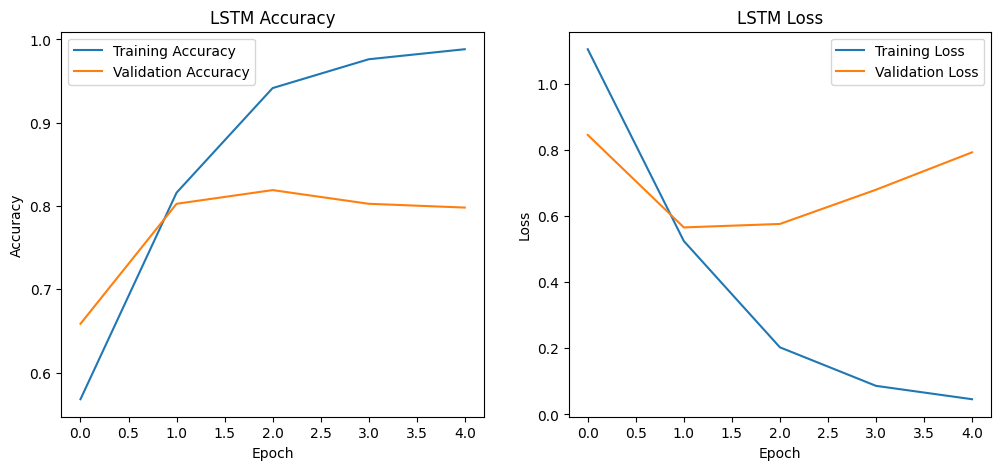

In [ ]:
plt.figure(figsize=(12,5))

# Accuracy graph
plt.subplot(1,2,1)
plt.plot(history_lstm.history['accuracy'])
plt.plot(history_lstm.history['val_accuracy'])

plt.title("LSTM Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.legend(['Training Accuracy', 'Validation Accuracy'])

# Loss graph
plt.subplot(1,2,2)
plt.plot(history_lstm.history['loss'])
plt.plot(history_lstm.history['val_loss'])

plt.title("LSTM Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.legend(['Training Loss', 'Validation Loss'])

plt.show()

## LSTM with pretrained Word2Vec embeddings

In [ ]:
embedding_model = api.load('glove-wiki-gigaword-50')

embedding_dim = 50
#creating embedding amtrix
embedding_matrix = np.zeros((vocab_size, embedding_dim))
for word, i in tokenizer.word_index.items():
    if word in embedding_model:
        embedding_vector = embedding_model[word]
        embedding_matrix[i] = embedding_vector
    else:
        pass

#building the LSTM model with pre trained mebedding layer
lstm_w2v_model = Sequential()
lstm_w2v_model.add(Embedding(
      input_dim=vocab_size,
      output_dim=embedding_dim,
      weights=[embedding_matrix],
      input_length=max_length,
      trainable=False))

lstm_w2v_model.add(LSTM(64))
lstm_w2v_model.add(Dense(num_classes, activation='softmax'))

lstm_w2v_model.build(input_shape=(None, max_length))
lstm_w2v_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ (None, 11, 50)         │       575,350 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 64)             │        29,440 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 5)              │           325 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 605,115 (2.31 MB)

 Trainable params: 29,765 (116.27 KB)

 Non-trainable params: 575,350 (2.19 MB)

In [ ]:
# compiling the model
lstm_w2v_model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
w2v_model_path = "/content/drive/MyDrive/lstm_word2vec_best_model.h5"
checkpoint = ModelCheckpoint( filepath=w2v_model_path, monitor='val_accuracy', save_best_only=True)
early_stop = EarlyStopping( monitor='val_loss', patience=3, restore_best_weights=True)

In [ ]:
start_time = time.time()

history_w2v = lstm_w2v_model.fit(
    X_train_pad,
    y_train_encoded,
    validation_split=0.2,
    epochs=15,
    batch_size=32,
    callbacks=[checkpoint, early_stop]
)

end_time = time.time()

print("Word2Vec LSTM Training Time:", end_time - start_time)

Epoch 1/15
219/221 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6030 - loss: 1.0064

221/221 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.7269 - loss: 0.7450 - val_accuracy: 0.8288 - val_loss: 0.5015
Epoch 2/15
217/221 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8268 - loss: 0.5168

221/221 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.8302 - loss: 0.4971 - val_accuracy: 0.8407 - val_loss: 0.4580
Epoch 3/15
213/221 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8438 - loss: 0.4507

221/221 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.8451 - loss: 0.4507 - val_accuracy: 0.8469 - val_loss: 0.4316
Epoch 4/15
219/221 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8559 - loss: 0.4248

221/221 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.8593 - loss: 0.4145 - val_accuracy: 0.8577 - val_loss: 0.4173
Epoch 5/15
221/221 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.8656 - loss: 0.3911 - val_accuracy: 0.8571 - val_loss: 0.4106
Epoch 6/15
217/221 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.8796 - loss: 0.3591

221/221 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - accuracy: 0.8744 - loss: 0.3623 - val_accuracy: 0.8628 - val_loss: 0.4019
Epoch 7/15
220/221 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8886 - loss: 0.3327

221/221 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.8886 - loss: 0.3318 - val_accuracy: 0.8651 - val_loss: 0.3947
Epoch 8/15
221/221 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.8988 - loss: 0.3064 - val_accuracy: 0.8583 - val_loss: 0.4167
Epoch 9/15
221/221 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.9038 - loss: 0.2837 - val_accuracy: 0.8605 - val_loss: 0.4072
Epoch 10/15
221/221 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.9131 - loss: 0.2603 - val_accuracy: 0.8498 - val_loss: 0.4377
Word2Vec LSTM Training Time: 24.818832874298096


### Model Evaluation

In [ ]:
lstm_w2v_model = load_model("/content/drive/MyDrive/lstm_word2vec_best_model.h5")
test_loss_w2v, test_accuracy_w2v = lstm_w2v_model.evaluate(X_test_pad, y_test_encoded)

print("Test Loss for LSTM w2v Model:", test_loss_w2v)
print("Test Accuracy for LSTM w2v Model:", test_accuracy_w2v)

69/69 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8508 - loss: 0.4545
Test Loss for LSTM w2v Model: 0.4545084834098816
Test Accuracy for LSTM w2v Model: 0.8507936596870422


In [ ]:
y_pred_probs = lstm_w2v_model.predict(X_test_pad)
y_pred_w2v = np.argmax(y_pred_probs, axis=1)

69/69 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step


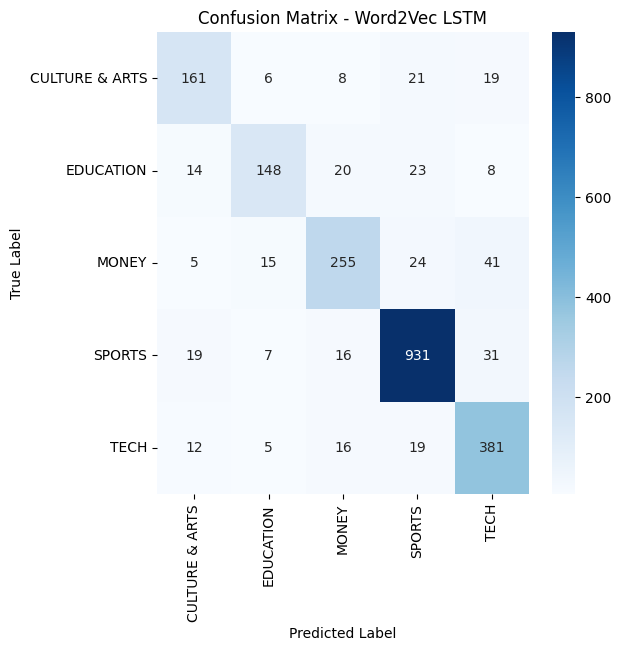

In [ ]:
confusion_matrix_w2v = confusion_matrix(y_test_encoded, y_pred_w2v)

plt.figure(figsize=(6,6))

sns.heatmap(confusion_matrix_w2v,annot=True, fmt='d', cmap='Blues',
            xticklabels=encoder.classes_,
            yticklabels=encoder.classes_)

plt.title("Confusion Matrix - Word2Vec LSTM")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.show()

In [ ]:
print(classification_report(y_test_encoded, y_pred_w2v))

              precision    recall  f1-score   support

           0       0.76      0.75      0.76       215
           1       0.82      0.69      0.75       213
           2       0.81      0.75      0.78       340
           3       0.91      0.93      0.92      1004
           4       0.79      0.88      0.83       433

    accuracy                           0.85      2205
   macro avg       0.82      0.80      0.81      2205
weighted avg       0.85      0.85      0.85      2205



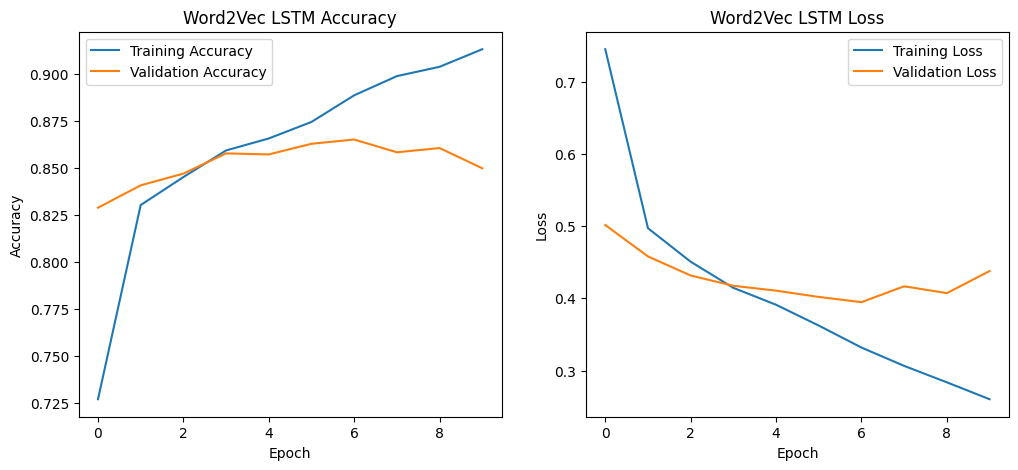

In [ ]:
plt.figure(figsize=(12,5))

# Accuracy graph
plt.subplot(1,2,1)
plt.plot(history_w2v.history['accuracy'])
plt.plot(history_w2v.history['val_accuracy'])

plt.title("Word2Vec LSTM Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.legend(['Training Accuracy', 'Validation Accuracy'])

# Loss graph
plt.subplot(1,2,2)
plt.plot(history_w2v.history['loss'])
plt.plot(history_w2v.history['val_loss'])

plt.title("Word2Vec LSTM Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.legend(['Training Loss', 'Validation Loss'])

plt.show()

## Model Comparison

In [ ]:
print("RNN Model")
print("Test Accuracy:", test_accuracy)
print("Test Loss:", test_loss)

print("\nLSTM Model")
print("Test Accuracy:", test_accuracy_lstm)
print("Test Loss:", test_loss_lstm)

print("\nWord2Vec LSTM Model")
print("Test Accuracy:", test_accuracy_w2v)
print("Test Loss:", test_loss_w2v)

RNN Model
Test Accuracy: 0.7931972742080688
Test Loss: 0.7383872270584106

LSTM Model
Test Accuracy: 0.8263038396835327
Test Loss: 0.5687466263771057

Word2Vec LSTM Model
Test Accuracy: 0.8507936596870422
Test Loss: 0.4545084834098816


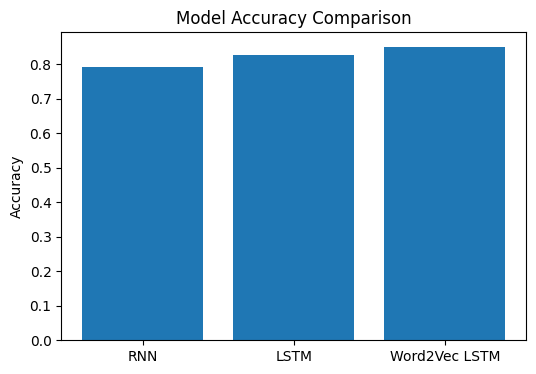

In [ ]:
models = ['RNN', 'LSTM', 'Word2Vec LSTM']
accuracy = [test_accuracy, test_accuracy_lstm, test_accuracy_w2v]

plt.figure(figsize=(6,4))
plt.bar(models, accuracy)
plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy")
plt.show()

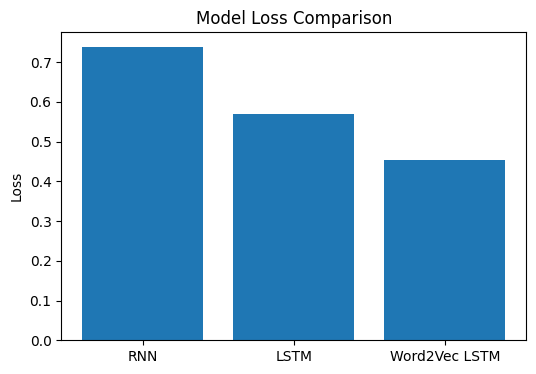

In [ ]:
loss = [test_loss, test_loss_lstm, test_loss_w2v]

plt.figure(figsize=(6,4))
plt.bar(models, loss)
plt.title("Model Loss Comparison")
plt.ylabel("Loss")
plt.show()

## 4.5.4 Error analysis

In [ ]:
#predictions
y_pred_rnn = np.argmax(rnn_model.predict(X_test_pad), axis=1)
#finding misclassified indices
wrong_indices = np.where(y_pred_rnn != y_test_encoded)[0]

print("Total wrong predictions:", len(wrong_indices))

69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
Total wrong predictions: 456


In [ ]:
for i in wrong_indices[:3]:
    print("\n--- Misclassified Example ---")

    print("Text:", tokenizer.sequences_to_texts([X_test_pad[i]])[0])
    print("True Label:", encoder.classes_[y_test_encoded[i]])
    print("Predicted Label:", encoder.classes_[y_pred_rnn[i]])


--- Misclassified Example ---
Text: college begin take transgender men next year
True Label: EDUCATION
Predicted Label: SPORTS

--- Misclassified Example ---
Text: chinese dilemma chinese students game college admissions
True Label: EDUCATION
Predicted Label: SPORTS

--- Misclassified Example ---
Text: take responsibility
True Label: CULTURE & ARTS
Predicted Label: MONEY


### Model Complexity vs Perfromance

The first mdel which was RNN had low complexity but it trained faster. The perfromance of SImple RNN model is limited because of weak handling of long term dependencies. Whereas, the LSTM model improved the perfomrance by using forget gets with helps in understanding the context. Similarly Word2Vec using LSTM performed more better because if used word embedding which gives meaning to the words.

The possible reason to the error might be due to unclear heading along with multiple meanins, the text might be short, some of the vocabulary between categories may be overlapping.

## GUI for real time prediction

In [ ]:
import gradio as gr


In [ ]:
def predict_category(text):
    # preprocessing
    seq = tokenizer.texts_to_sequences([text])
    padded = pad_sequences(seq, maxlen=max_length)
    # prediction
    pred = lstm_w2v_model.predict(padded)
    label = encoder.classes_[np.argmax(pred)]

    return label
interface = gr.Interface(
    fn=predict_category,
    inputs=gr.Textbox(lines=2, placeholder="Enter a headline..."),
    outputs="text",
    title="News Category Prediction System",
    description="Enter a news headline and the model will predict its category (TECH, SPORTS, EDUCATION, etc.)"
)

interface.launch()

It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://a349cf629ac1b760c8.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
